# Matrix Multiplication: From Python to CUDA

**TU Wien — Machine Learning (Master)**

Matrix multiplication is *the* core operation in deep learning. This notebook explores how implementation choices affect performance, progressing from the simplest possible code to GPU-accelerated kernels.

We compute $C = A \times B$ where $A \in \mathbb{R}^{M \times K}$, $B \in \mathbb{R}^{K \times N}$, $C \in \mathbb{R}^{M \times N}$.

$$C_{ij} = \sum_{k=1}^{K} A_{ik} \cdot B_{kj}$$

**Roadmap:**
1. Pure Python — triple `for` loop (painfully slow)
2. C (naive `ijk`) — same algorithm, compiled code
3. C (cache-friendly `ikj`) — loop reordering for memory locality
4. C (tiled) — blocking for L1 cache reuse
5. CUDA (naive) — one GPU thread per output element
6. CUDA (shared-memory tiled) — cooperative tile loading
7. NumPy / PyTorch — optimized BLAS & cuBLAS baselines

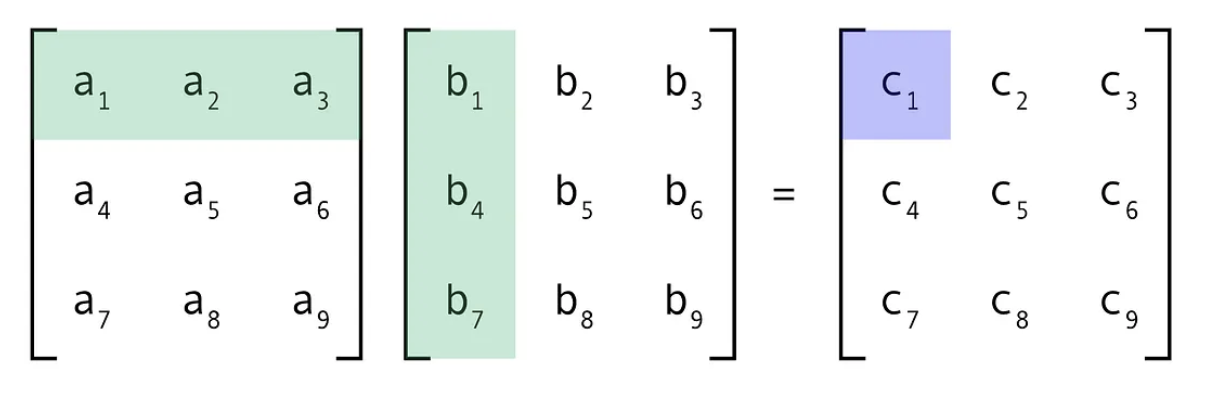

In [29]:
import numpy as np
import ctypes, os, time, subprocess

# Matrix dimensions — keep small enough for Python, large enough to see differences
M, K, N = 256, 256, 256

np.random.seed(42)
A = np.random.randn(M, K).astype(np.float32)
B = np.random.randn(K, N).astype(np.float32)

t0 = time.perf_counter()
C_ref = A @ B  # reference result for correctness checks
t_python = time.perf_counter() - t0
print(f"  ⏱ numpy: {t_python:.3f}s")

def check(C_test, label, rtol=1e-4, atol=1e-3):
    """Verify result against numpy reference."""
    if np.allclose(C_test, C_ref, rtol=rtol, atol=atol):
        print(f"  ✓ {label}: correct")
    else:
        max_err = np.max(np.abs(C_test - C_ref))
        print(f"  ✗ {label}: max error = {max_err:.6f}")

print(f"Matrix sizes: A={A.shape}, B={B.shape}, C={C_ref.shape}")
print(f"Total multiply-add operations: {M*K*N:,}")

  ⏱ numpy: 0.009s
Matrix sizes: A=(256, 256), B=(256, 256), C=(256, 256)
Total multiply-add operations: 16,777,216


## 1. Pure Python — Triple `for` Loop

The most straightforward implementation: three nested loops directly implementing the summation formula. This is $O(M \cdot K \cdot N)$ — and every operation goes through the Python interpreter.

In [30]:
def python_matmul(A, B):
    M, K = A.shape
    K2, N = B.shape
    C = np.zeros((M, N), dtype=np.float32)
    for i in range(M):
        for j in range(N):
            s = 0.0
            for k in range(K):
                s += A[i, k] * B[k, j]
            C[i, j] = s
    return C

t0 = time.perf_counter()
C_py = python_matmul(A, B)
t_python = time.perf_counter() - t0

check(C_py, "Python")
print(f"  ⏱ Python: {t_python:.3f}s")

  ✓ Python: correct
  ⏱ Python: 2.843s


## 2. C — Naive `ijk` Order (via ctypes)

Same triple-loop algorithm, but compiled to native machine code. We load the shared library with `ctypes` and pass numpy arrays directly (they are contiguous C arrays in memory).

**Why is this faster?** No interpreter overhead, the compiler can use SIMD instructions, and there's no per-element Python object boxing/unboxing.

In [31]:
# Compile the C library
subprocess.run(["gcc", "-O2", "-shared", "-fPIC", "-o", "matmul.so", "matmul.c"], check=True)
lib = ctypes.CDLL("./matmul.so")

# Set up function signatures
F = ctypes.c_float
P = ctypes.POINTER(F)
I = ctypes.c_int
for fn_name in ["matmul_naive", "matmul_cache_friendly", "matmul_tiled"]:
    fn = getattr(lib, fn_name)
    fn.restype = None
    fn.argtypes = [P, P, P, I, I, I]

def call_c(fn, A, B):
    """Call a C matmul function with numpy arrays."""
    M, K = A.shape
    _, N = B.shape
    C = np.zeros((M, N), dtype=np.float32)
    fn(A.ctypes.data_as(P), B.ctypes.data_as(P), C.ctypes.data_as(P), M, N, K)
    return C

In [32]:
t0 = time.perf_counter()
C_c_naive = call_c(lib.matmul_naive, A, B)
t_c_naive = time.perf_counter() - t0

check(C_c_naive, "C naive")
print(f"  ⏱ C naive:  {t_c_naive*1000:.2f}ms  ({t_python/t_c_naive:.0f}× faster than Python)")

  ✓ C naive: correct
  ⏱ C naive:  11.13ms  (256× faster than Python)


## 3. C — Cache-Friendly `ikj` Loop Order

The key insight: **loop order matters because of how memory is laid out.**

In row-major (C) order, `B[k][j]` for varying `j` is contiguous in memory, but `B[k][j]` for varying `k` (as in the naive inner loop) jumps across rows — causing cache misses.

By reordering to `ikj`, the inner loop sweeps across `B[k][j]` and `C[i][j]` sequentially:

```
Naive (ijk):                Cache-friendly (ikj):
for i:                      for i:
  for j:                      for k:
    for k:  ← B[k][j]          a_ik = A[i][k]   ← reused scalar
      C[i][j] += A[i][k]       for j:            ← sequential sweep
                 * B[k][j]        C[i][j] += a_ik * B[k][j]
      ↑ jumps in memory                           ↑ sequential!
```

This simple change can yield **5–10× speedup** on large matrices, purely from better cache utilization.
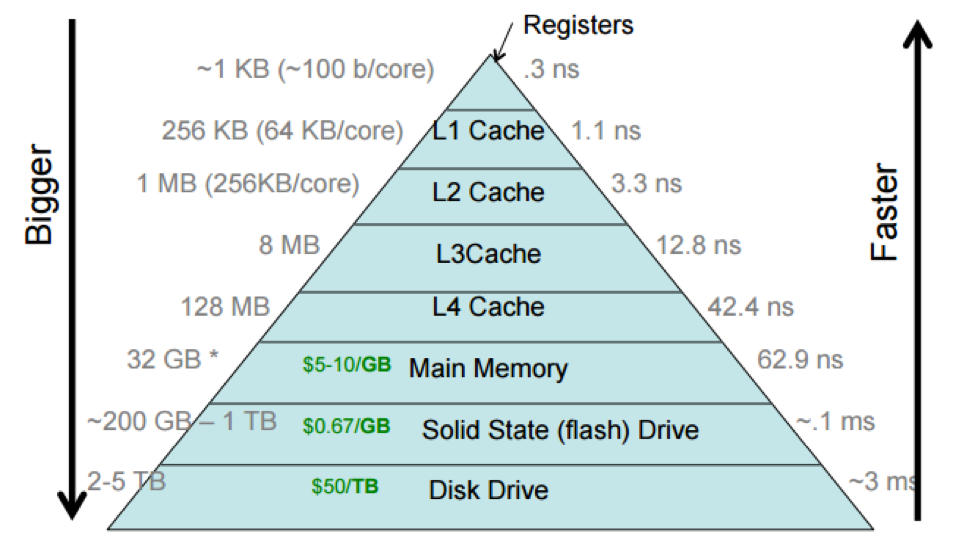

In [33]:
t0 = time.perf_counter()
C_c_cf = call_c(lib.matmul_cache_friendly, A, B)
t_c_cf = time.perf_counter() - t0

check(C_c_cf, "C cache-friendly")
print(f"  ⏱ C cache-friendly: {t_c_cf*1000:.2f}ms  ({t_c_naive/t_c_cf:.1f}× faster than C naive)")

  ✓ C cache-friendly: correct
  ⏱ C cache-friendly: 12.46ms  (0.9× faster than C naive)


## 4. C — Loop Tiling (Blocking)

![image.png](attachment:baca5537-743e-46c9-81a9-4c089046476a.png)

**Figure: Memory hierarchy of size and access latency** (source: https://cs.brown.edu/courses/csci1310/2020/assign/labs/lab4.html?spm=a2c65.11461447.0.0.47497f65qeXgJJ)


Tiling goes further: instead of processing full rows/columns, we work on small `TILE×TILE` sub-blocks that fit entirely in L1 cache (~32KB). Each tile is reused multiple times before eviction.

```
for each tile (i0, k0, j0):
    load A[i0:i0+T, k0:k0+T]  → fits in L1
    load B[k0:k0+T, j0:j0+T]  → fits in L1
    multiply and accumulate into C[i0:i0+T, j0:j0+T]
```

With `TILE=32`, each tile is `32×32×4 bytes = 4KB` — three tiles easily fit in a 32KB L1 cache.

In [34]:
t0 = time.perf_counter()
C_c_tiled = call_c(lib.matmul_tiled, A, B)
t_c_tiled = time.perf_counter() - t0

check(C_c_tiled, "C tiled")
print(f"  ⏱ C tiled: {t_c_tiled*1000:.2f}ms  ({t_c_naive/t_c_tiled:.1f}× faster than C naive)")

  ✓ C tiled: correct
  ⏱ C tiled: 8.07ms  (1.4× faster than C naive)


## 5. CUDA — Naive Kernel

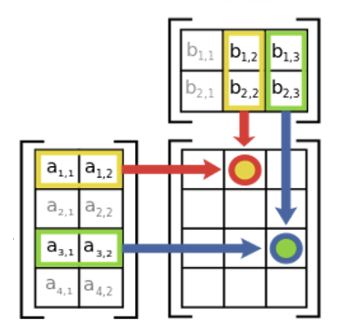

Now we move to the GPU. The simplest CUDA approach: launch one thread per output element of C. Each thread independently computes the dot product of a row of A and a column of B.

```
Thread (row, col):
    C[row][col] = sum_k A[row][k] * B[k][col]
```

With a 16×16 thread block, we need `(N/16) × (M/16)` blocks to cover the entire output matrix. The GPU executes thousands of threads in parallel.

In [35]:
# Compile the CUDA library
subprocess.run(["nvcc", "--std=c++14", "-shared", "-Xcompiler", "-fPIC",
                 "-o", "matmul_cuda.so", "matmul_cuda.cu"], check=True)
cuda_lib = ctypes.CDLL("./matmul_cuda.so")

for fn_name in ["cuda_matmul_naive", "cuda_matmul_tiled"]:
    fn = getattr(cuda_lib, fn_name)
    fn.restype = None
    fn.argtypes = [P, P, P, I, I, I]

def call_cuda(fn, A, B):
    """Call a CUDA matmul function (handles host↔device transfers internally)."""
    M, K = A.shape
    _, N = B.shape
    C = np.zeros((M, N), dtype=np.float32)
    fn(A.ctypes.data_as(P), B.ctypes.data_as(P), C.ctypes.data_as(P), M, N, K)
    return C

In [36]:
# Warmup (first CUDA call has overhead from context initialization)
_ = call_cuda(cuda_lib.cuda_matmul_naive, A, B)

t0 = time.perf_counter()
C_cuda_naive = call_cuda(cuda_lib.cuda_matmul_naive, A, B)
t_cuda_naive = time.perf_counter() - t0

check(C_cuda_naive, "CUDA naive")
print(f"  ⏱ CUDA naive: {t_cuda_naive*1000:.2f}ms  ({t_c_naive/t_cuda_naive:.1f}× faster than C naive)")

  ✓ CUDA naive: correct
  ⏱ CUDA naive: 0.30ms  (37.6× faster than C naive)


## 6. CUDA — Shared-Memory Tiled Kernel

The same tiling idea from CPU, but adapted for the GPU memory hierarchy:

- **Global memory** (VRAM): high bandwidth but high latency (~400 cycles)
- **Shared memory**: small (~48KB per block), but very fast (~5 cycles)

Each thread block cooperatively loads a tile of A and B into shared memory, then all threads in the block compute using the fast shared memory. This reduces global memory reads by a factor of `TILE_SIZE`.

```
for each tile t:
    All threads load A_tile[ty][tx] and B_tile[ty][tx] from global → shared
    __syncthreads()                 ← wait for all threads
    Each thread: sum += A_tile[ty][k] * B_tile[k][tx]  for k in tile
    __syncthreads()
```

In [37]:
t0 = time.perf_counter()
C_cuda_tiled = call_cuda(cuda_lib.cuda_matmul_tiled, A, B)
t_cuda_tiled = time.perf_counter() - t0

check(C_cuda_tiled, "CUDA tiled")
print(f"  ⏱ CUDA tiled: {t_cuda_tiled*1000:.2f}ms  ({t_cuda_naive/t_cuda_tiled:.1f}× faster than CUDA naive)")

  ✓ CUDA tiled: correct
  ⏱ CUDA tiled: 0.54ms  (0.5× faster than CUDA naive)


## 7. Library Baselines: NumPy & PyTorch

How do our implementations compare to production libraries?

- **NumPy** calls optimized BLAS (OpenBLAS/MKL) — multi-threaded, vectorized, cache-optimized
- **PyTorch CPU** also calls BLAS
- **PyTorch CUDA** calls cuBLAS — NVIDIA's hand-tuned GPU implementation

In [38]:
import torch

# NumPy (BLAS)
t0 = time.perf_counter()
C_np = A @ B
t_numpy = time.perf_counter() - t0
print(f"  ⏱ NumPy (BLAS):      {t_numpy*1000:.2f}ms")

# PyTorch CPU
A_t = torch.from_numpy(A)
B_t = torch.from_numpy(B)
t0 = time.perf_counter()
C_torch_cpu = A_t @ B_t
t_torch_cpu = time.perf_counter() - t0
print(f"  ⏱ PyTorch CPU:       {t_torch_cpu*1000:.2f}ms")

# PyTorch CUDA
A_g = A_t.cuda()
B_g = B_t.cuda()
# Warmup
_ = A_g @ B_g
torch.cuda.synchronize()

t0 = time.perf_counter()
C_torch_gpu = A_g @ B_g
torch.cuda.synchronize()
t_torch_gpu = time.perf_counter() - t0
print(f"  ⏱ PyTorch CUDA:      {t_torch_gpu*1000:.2f}ms")

  ⏱ NumPy (BLAS):      3.83ms
  ⏱ PyTorch CPU:       8.84ms
  ⏱ PyTorch CUDA:      0.08ms


## 8. Summary Table

In [39]:
print("=" * 60)
print(f"{'Method':<25} {'Time':>10}  {'vs Python':>10}")
print("=" * 60)

results = [
    ("Python (3 loops)",       t_python),
    ("C naive (ijk)",          t_c_naive),
    ("C cache-friendly (ikj)", t_c_cf),
    ("C tiled",                t_c_tiled),
    ("CUDA naive",             t_cuda_naive),
    ("CUDA tiled (shmem)",     t_cuda_tiled),
    ("NumPy (BLAS)",           t_numpy),
    ("PyTorch CPU",            t_torch_cpu),
    ("PyTorch CUDA",           t_torch_gpu),
]

for name, t in results:
    if t >= 1.0:
        tstr = f"{t:.2f}s"
    else:
        tstr = f"{t*1000:.2f}ms"
    speedup = t_python / t
    print(f"  {name:<23} {tstr:>10}  {speedup:>9.0f}×")

print("=" * 60)
print(f"\nMatrix size: {M}×{K} @ {K}×{N}  ({M*K*N:,} multiply-adds)")

Method                          Time   vs Python
  Python (3 loops)             2.84s          1×
  C naive (ijk)              11.13ms        256×
  C cache-friendly (ikj)     12.46ms        228×
  C tiled                     8.07ms        352×
  CUDA naive                  0.30ms       9611×
  CUDA tiled (shmem)          0.54ms       5242×
  NumPy (BLAS)                3.83ms        742×
  PyTorch CPU                 8.84ms        322×
  PyTorch CUDA                0.08ms      34300×

Matrix size: 256×256 @ 256×256  (16,777,216 multiply-adds)


## 9. Scaling Test — Larger Matrices

At 256×256, the GPU is underutilized (not enough parallelism to hide latency). Let's try larger sizes where the GPU really shines. We skip pure Python here (it would take minutes).

In [40]:
sizes = [256, 512, 1024, 2048]
methods_large = {
    "C tiled":         lambda A, B: call_c(lib.matmul_tiled, A, B),
    "CUDA naive":      lambda A, B: call_cuda(cuda_lib.cuda_matmul_naive, A, B),
    "CUDA tiled":      lambda A, B: call_cuda(cuda_lib.cuda_matmul_tiled, A, B),
    "NumPy":           lambda A, B: A @ B,
    "PyTorch CUDA":    None,  # handled separately
}

print(f"{'Size':>6}", end="")
for name in methods_large:
    print(f"  {name:>14}", end="")
print()
print("-" * (6 + 16 * len(methods_large)))

for sz in sizes:
    A_big = np.random.randn(sz, sz).astype(np.float32)
    B_big = np.random.randn(sz, sz).astype(np.float32)
    print(f"{sz:>5} ", end="")

    for name, fn in methods_large.items():
        if name == "PyTorch CUDA":
            At = torch.from_numpy(A_big).cuda()
            Bt = torch.from_numpy(B_big).cuda()
            _ = At @ Bt; torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = At @ Bt
            torch.cuda.synchronize()
            t = time.perf_counter() - t0
        else:
            _ = fn(A_big, B_big)  # warmup
            t0 = time.perf_counter()
            _ = fn(A_big, B_big)
            t = time.perf_counter() - t0
        print(f"  {t*1000:>12.2f}ms", end="")
    print()

  Size         C tiled      CUDA naive      CUDA tiled           NumPy    PyTorch CUDA
--------------------------------------------------------------------------------------
  256           6.41ms          0.20ms          0.20ms          0.17ms          0.03ms
  512          61.35ms          1.68ms          1.95ms          2.47ms          0.09ms
 1024         471.57ms          4.62ms          3.90ms          5.06ms          0.33ms
 2048        3736.42ms         38.76ms         33.85ms         31.38ms          3.25ms


## 10. Batched Matrix Multiplication

In deep learning, we rarely multiply single matrices. Instead, we have **batches** — e.g., a batch of 32 inputs, each requiring its own matmul. This is what `torch.bmm` or `@` with a batch dimension does.

Key insight: batched matmul on GPU is highly efficient because all batch elements run in parallel, fully utilizing the GPU's massive parallelism.

In [41]:
batch_size = 32
seq_len = 128
d_model = 512

# Simulates attention: Q @ K^T for a batch of sequences
Q = torch.randn(batch_size, seq_len, d_model, device="cuda")
K = torch.randn(batch_size, seq_len, d_model, device="cuda")

# Warmup
_ = torch.bmm(Q, K.transpose(1, 2))
torch.cuda.synchronize()

# Batched matmul
t0 = time.perf_counter()
attn_scores = torch.bmm(Q, K.transpose(1, 2))  # [B, seq, seq]
torch.cuda.synchronize()
t_batched = time.perf_counter() - t0
print(f"Batched matmul: {batch_size}× [{seq_len}×{d_model}] @ [{d_model}×{seq_len}]")
print(f"  Output shape: {attn_scores.shape}")
print(f"  ⏱ {t_batched*1000:.2f}ms")
print(f"  Total multiply-adds: {batch_size * seq_len * seq_len * d_model:,}")

# Compare: sequential loop vs batched
t0 = time.perf_counter()
for i in range(batch_size):
    _ = Q[i] @ K[i].T
torch.cuda.synchronize()
t_sequential = time.perf_counter() - t0
print(f"\n  Sequential loop:  {t_sequential*1000:.2f}ms")
print(f"  Batched (bmm):    {t_batched*1000:.2f}ms")
print(f"  Speedup:          {t_sequential/t_batched:.1f}×")

Batched matmul: 32× [128×512] @ [512×128]
  Output shape: torch.Size([32, 128, 128])
  ⏱ 0.23ms
  Total multiply-adds: 268,435,456

  Sequential loop:  1.37ms
  Batched (bmm):    0.23ms
  Speedup:          6.1×
